In [1]:

from nptdms import TdmsFile 
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.signal
from scipy.optimize import curve_fit  # For curve fitting
import pandas as pd
import statistics
from math import *
import pyfmreader.ps_nex.parseTDMS as tdms

import pyfmreader.uff as uff
from pyfmreader.ps_nex import loadPSNEXfile

from pyfmreader import loadfile

In [2]:
directory = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/600'
first_file, all_files = tdms.grab_tdms(directory)

PSNEX.tdms
Height channel: Zpiezo_stage_sensor_(V)
Deflection Sens.: 1.69e-08 m/V
Spring Constant: 0.1 N/m
decimation: [10 10 10]
z_sensor_delay: 0.001, bool_correct_overshoot: False 
points removed : 50
start_indices: [    0 56355 57420]
end_indices: [56355 57420 59115]
NumPnts: [56355  1065  1695]
Deflection Length: 59066, Height: 59066
0 56355
segment relative position: 56355, segment duration: 1.12710425
App
removed overshoot
---------------------
56355 57420
segment relative position: 1065, segment duration: 0.0213145
Con
---------------------
57420 59066
segment relative position: 1646, segment duration: 0.033903474999999995
Ret
---------------------
Segment types: ['App', 'Con', 'Ret']
Segment 0: Approach, 0:56355
Segment 1: Contact, #pnts: 1065
Segment 2: Retract, 57420:59066
1.9999999999999998e-05 56355
1.9999999999999998e-05 1065
1.9999999999999998e-05 1695


(array([2.52990875e-05, 2.52990875e-05, 2.53010101e-05, ...,
        3.25257626e-05, 3.25103817e-05, 3.24950023e-05]),
 array([-6.61023753e-09, -6.53441062e-09, -6.57124221e-09, ...,
        -7.29594340e-09, -7.18545265e-09, -7.22120037e-09]),
 0.1,
 16.9,
 1.69e-08,
 1,
 np.int64(56355),
 np.int64(0),
 array([    0, 56355, 57420]),
 np.int64(59066),
 1065,
 array([0.000e+00, 2.000e-05, 4.000e-05, ..., 3.384e-02, 3.386e-02,
        3.388e-02]))

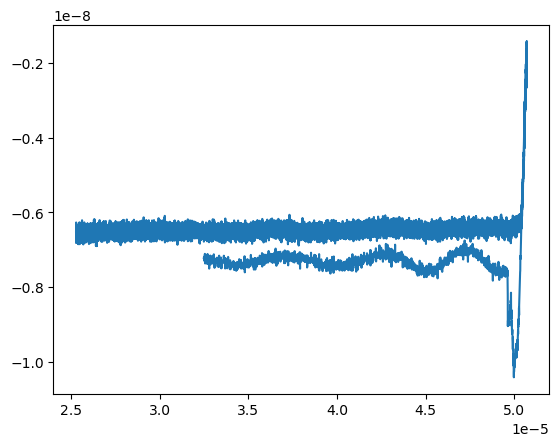

In [3]:
# Load File
file = loadfile(all_files[0])
filemetadata = file.filemetadata
print(filemetadata['file_type'])

# metadata
file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
K = filemetadata['spring_const_Nbym'] #N/m
height_channel = filemetadata['height_channel_key']

deflection_sensitivity = file_deflection_sensitivity / 1e9 #m/V
invOLS = filemetadata['invOLS_(nm/V)']

# print(f"Closed loop: {closed_loop}")
print(f"Height channel: {height_channel}")
print(f"Deflection Sens.: {deflection_sensitivity} m/V")
print(f"Spring Constant: {K} N/m")

# Select curve by index
curve_idx = 0
force_curve = file.getcurve(curve_idx, bool_correct_overshoot=False)

start_indices = filemetadata['start_indices']
end_indices = filemetadata['end_indices']
nm_pnts = filemetadata['numPnts']

# Preprocess curve
force_curve.preprocess_force_curve(deflection_sensitivity, height_channel)

# To get each segment
fc_segments = force_curve.get_segments()
n_segments = len(fc_segments)
segment_types = [segment.segment_type for _, segment in fc_segments]
print("Segment types:", segment_types)


for segid, segment in fc_segments:
    seg_type = segment.segment_type.lower()
    if seg_type == 'app':
        # You can add specific processing for approach here
        index_end_approach = end_indices[segid]
        index_start_approach = start_indices[segid]
        print(f"Segment {segid}: Approach, {index_start_approach}:{index_end_approach}")
    elif seg_type == 'con':
        # You can add specific processing for contact here
        contact_pts  = nm_pnts[segid]
        print(f"Segment {segid}: Contact, #pnts: {contact_pts}")
    elif seg_type == 'ret':
        # You can add specific processing for retract here
        index_end_retract = end_indices[segid]
        index_start_retract = start_indices[segid]
        print(f"Segment {segid}: Retract, {index_start_retract}:{index_end_retract}")
    else:
        print(f"Segment {segid}: Unknown type '{segment.segment_type}'")

zheight_list = []
vdeflection_list = []
time_list = []

relative_dt = filemetadata['relative_sr']

for dt, nm_pnt in zip(relative_dt, nm_pnts):
    print(dt, nm_pnt)
    # Create a time array for each segment based on dt and number of points
    time_segment = np.arange(nm_pnt) * dt
    time_list.append(time_segment)


for segid, segment in fc_segments:
    zheight_list.append(segment.zheight)
    vdeflection_list.append(segment.vdeflection)

distance_nm = np.concatenate(zheight_list)
force_pN = np.concatenate(vdeflection_list)
piezo_gain = 1 # not implemented, Forced to 1

time = np.concatenate(time_list)


index_start_retract = start_indices

plt.plot(distance_nm, force_pN)
distance_nm, force_pN, K, invOLS, deflection_sensitivity, piezo_gain, index_end_approach, index_start_approach, index_start_retract, index_end_retract, int(contact_pts),time

In [4]:
# channel_dict, time = tdms.process_tdms_file(first_file)
# channel_keys = channel_dict.keys()

# for key in channel_keys:
#     print (f'channels: {key}')

# channel_keys_list = list(channel_keys)
# # print(channel_dict[channel_keys_list[0]])
# # print(channel_dict[channel_keys_list[1]])


# channel_defl_V = channel_dict[channel_keys_list[0]]
# channel_piezo_V = channel_dict[channel_keys_list[1]]
#plot piezo vs deflection
# plt.plot(channel_piezo_V, channel_defl_V)

# uff_obj = uff.UFF()

# uff_metdata = loadPSNEXfile(first_file, uff_obj)
# file_metadata = uff_obj.filemetadata
# curve_properties = file_metadata['curve_properties']


PSNEX.tdms
Height channel: Zpiezo_stage_sensor_(V)
Deflection Sens.: 1.69e-08 m/V
Spring Constant: 0.1 N/m
decimation: [10 10 10]
z_sensor_delay: 0.001, bool_correct_overshoot: False 
points removed : 50
start_indices: [    0 56355 57420]
end_indices: [56355 57420 59115]
NumPnts: [56355  1065  1695]
Deflection Length: 59066, Height: 59066
0 56355
segment relative position: 56355, segment duration: 1.12710425
App
removed overshoot
---------------------
56355 57420
segment relative position: 1065, segment duration: 0.0213145
Con
---------------------
57420 59066
segment relative position: 1646, segment duration: 0.033903474999999995
Ret
---------------------
Segment types: ['App', 'Con', 'Ret']
Segment 0: Approach, 0:56355
Segment 1: Contact, #pnts: 1065
Segment 2: Retract, 57420:59066
1.9999999999999998e-05 56355
1.9999999999999998e-05 1065
1.9999999999999998e-05 1695


(array([2.52990875e-05, 2.52990875e-05, 2.53010101e-05, ...,
        3.25257626e-05, 3.25103817e-05, 3.24950023e-05]),
 array([-6.61023753e-09, -6.53441062e-09, -6.57124221e-09, ...,
        -7.29594340e-09, -7.18545265e-09, -7.22120037e-09]),
 0.1,
 16.9,
 1.69e-08,
 1,
 np.int64(56355),
 np.int64(0),
 array([    0, 56355, 57420]),
 np.int64(59066),
 1065,
 array([0.000e+00, 2.000e-05, 4.000e-05, ..., 3.384e-02, 3.386e-02,
        3.388e-02]))

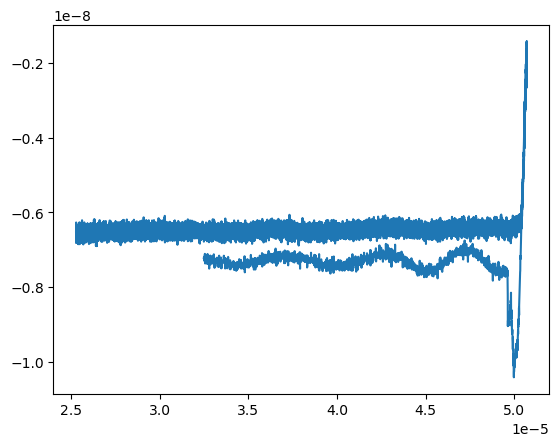

In [5]:
directory = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/600'
first_file, all_files = tdms.grab_tdms(directory)

# Load File
file = loadfile(all_files[0])
filemetadata = file.filemetadata
print(filemetadata['file_type'])

# metadata
file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
K = filemetadata['spring_const_Nbym'] #N/m
height_channel = filemetadata['height_channel_key']

deflection_sensitivity = file_deflection_sensitivity / 1e9 #m/V
invOLS = filemetadata['invOLS_(nm/V)']

# print(f"Closed loop: {closed_loop}")
print(f"Height channel: {height_channel}")
print(f"Deflection Sens.: {deflection_sensitivity} m/V")
print(f"Spring Constant: {K} N/m")

# Select curve by index
curve_idx = 0
force_curve = file.getcurve(curve_idx, bool_correct_overshoot=False)

start_indices = filemetadata['start_indices']
end_indices = filemetadata['end_indices']
nm_pnts = filemetadata['numPnts']

# Preprocess curve
force_curve.preprocess_force_curve(deflection_sensitivity, height_channel)

# To get each segment
fc_segments = force_curve.get_segments()
n_segments = len(fc_segments)
segment_types = [segment.segment_type for _, segment in fc_segments]
print("Segment types:", segment_types)


for segid, segment in fc_segments:
    seg_type = segment.segment_type.lower()
    if seg_type == 'app':
        # You can add specific processing for approach here
        index_end_approach = end_indices[segid]
        index_start_approach = start_indices[segid]
        print(f"Segment {segid}: Approach, {index_start_approach}:{index_end_approach}")
    elif seg_type == 'con':
        # You can add specific processing for contact here
        contact_pts  = nm_pnts[segid]
        print(f"Segment {segid}: Contact, #pnts: {contact_pts}")
    elif seg_type == 'ret':
        # You can add specific processing for retract here
        index_end_retract = end_indices[segid]
        index_start_retract = start_indices[segid]
        print(f"Segment {segid}: Retract, {index_start_retract}:{index_end_retract}")
    else:
        print(f"Segment {segid}: Unknown type '{segment.segment_type}'")

zheight_list = []
vdeflection_list = []
time_list = []

relative_dt = filemetadata['relative_sr']

for dt, nm_pnt in zip(relative_dt, nm_pnts):
    print(dt, nm_pnt)
    # Create a time array for each segment based on dt and number of points
    time_segment = np.arange(nm_pnt) * dt
    time_list.append(time_segment)


for segid, segment in fc_segments:
    zheight_list.append(segment.zheight)
    vdeflection_list.append(segment.vdeflection)

distance_nm = np.concatenate(zheight_list)
force_pN = np.concatenate(vdeflection_list)
piezo_gain = 1 # not implemented, Forced to 1

time = np.concatenate(time_list)


index_start_retract = start_indices

plt.plot(distance_nm, force_pN)
distance_nm, force_pN, K, invOLS, deflection_sensitivity, piezo_gain, index_end_approach, index_start_approach, index_start_retract, index_end_retract, int(contact_pts),time

In [6]:
def GetForceDistAndParms_psnex(directory):

    """
    This function converts deflection & piezo mouvement
    and extract the information from the TDMS file located in the "Force Curve" group

    Parameters
    ----------
    directory : str
        the current directory containing the parameter file
    channel_data_deflection : np array
        a matrix containing the deflection data in volts.
    channel_data_piezo : np array
        a matrix containing the pizeo mouvement in volts.
    time : np array
        time array in whatever units the in input

    Returns
    -------
    distance : list
        the distance in nanometer (indentation/separation ).
    force : list
        the force in pN.
    K : float
        K represents the spring constant.
    invOLS : float
        (nm/V)
    Sensitivity: float
        in (nm/V).

    """
    directory = '/Users/evillz/Data/article/2025_07_01_THP1_phd/cell2/600'
    first_file, all_files = tdms.grab_tdms(directory)

    # Load File
    file = loadfile(all_files[0])
    filemetadata = file.filemetadata
    print(filemetadata['file_type'])

    # metadata
    file_deflection_sensitivity = filemetadata['defl_sens_nmbyV'] #nm/V
    K = filemetadata['spring_const_Nbym'] #N/m
    height_channel = filemetadata['height_channel_key']

    deflection_sensitivity = file_deflection_sensitivity / 1e9 #m/V
    invOLS = filemetadata['invOLS_(nm/V)']

    # print(f"Closed loop: {closed_loop}")
    print(f"Height channel: {height_channel}")
    print(f"Deflection Sens.: {deflection_sensitivity} m/V")
    print(f"Spring Constant: {K} N/m")

    # Select curve by index
    curve_idx = 0
    force_curve = file.getcurve(curve_idx, bool_correct_overshoot=False)

    start_indices = filemetadata['start_indices']
    end_indices = filemetadata['end_indices']
    nm_pnts = filemetadata['numPnts']

    # Preprocess curve
    force_curve.preprocess_force_curve(deflection_sensitivity, height_channel)

    # To get each segment
    fc_segments = force_curve.get_segments()
    n_segments = len(fc_segments)
    segment_types = [segment.segment_type for _, segment in fc_segments]
    print("Segment types:", segment_types)


    for segid, segment in fc_segments:
        seg_type = segment.segment_type.lower()
        if seg_type == 'app':
            # You can add specific processing for approach here
            index_end_approach = end_indices[segid]
            index_start_approach = start_indices[segid]
            print(f"Segment {segid}: Approach, {index_start_approach}:{index_end_approach}")
        elif seg_type == 'con':
            # You can add specific processing for contact here
            contact_pts  = nm_pnts[segid]
            print(f"Segment {segid}: Contact, #pnts: {contact_pts}")
        elif seg_type == 'ret':
            # You can add specific processing for retract here
            index_end_retract = end_indices[segid]
            index_start_retract = start_indices[segid]
            print(f"Segment {segid}: Retract, {index_start_retract}:{index_end_retract}")
        else:
            print(f"Segment {segid}: Unknown type '{segment.segment_type}'")

    zheight_list = []
    vdeflection_list = []
    time_list = []

    relative_dt = filemetadata['relative_sr']

    for dt, nm_pnt in zip(relative_dt, nm_pnts):
        print(dt, nm_pnt)
        # Create a time array for each segment based on dt and number of points
        time_segment = np.arange(nm_pnt) * dt
        time_list.append(time_segment)


    for segid, segment in fc_segments:
        zheight_list.append(segment.zheight)
        vdeflection_list.append(segment.vdeflection)

    distance_nm = np.concatenate(zheight_list)
    force_pN = np.concatenate(vdeflection_list)
    piezo_gain = 1 # not implemented, Forced to 1
    time = np.concatenate(time_list)

    # plt.plot(distance_nm, force_pN)
    return distance_nm, force_pN, K, invOLS, deflection_sensitivity, piezo_gain, index_end_approach, index_start_approach, index_start_retract, index_end_retract, int(contact_pts),time


In [7]:
distance_nm, force_pN, K, invOLS, deflection_sensitivity, piezo_gain, index_end_approach, index_start_approach, index_start_retract, index_end_retract, contact_pts,time = GetForceDistAndParms_psnex(directory)


PSNEX.tdms
Height channel: Zpiezo_stage_sensor_(V)
Deflection Sens.: 1.69e-08 m/V
Spring Constant: 0.1 N/m
decimation: [10 10 10]
z_sensor_delay: 0.001, bool_correct_overshoot: False 
points removed : 50
start_indices: [    0 56355 57420]
end_indices: [56355 57420 59115]
NumPnts: [56355  1065  1695]
Deflection Length: 59066, Height: 59066
0 56355
segment relative position: 56355, segment duration: 1.12710425
App
removed overshoot
---------------------
56355 57420
segment relative position: 1065, segment duration: 0.0213145
Con
---------------------
57420 59066
segment relative position: 1646, segment duration: 0.033903474999999995
Ret
---------------------
Segment types: ['App', 'Con', 'Ret']
Segment 0: Approach, 0:56355
Segment 1: Contact, #pnts: 1065
Segment 2: Retract, 57420:59066
1.9999999999999998e-05 56355
1.9999999999999998e-05 1065
1.9999999999999998e-05 1695
